In [1]:
import pandas as pd

data = pd.DataFrame({
    "age": [66,52,22,25,44,39,26,40,53,64,58,33],
    "cars": [1,2,0,1,0,1,1,3,2,2,2,1],
    "house": ["yes","yes","no","no","no","yes","no","yes","yes","yes","yes","no"],
    "children": [2,3,0,1,2,2,2,1,2,3,2,1],
    "marital": ["widowed","married","married","single","divorced","married","single","married","divorced","divorced","married","single"],
    "dog": ["no","no","yes","no","yes","yes","no","yes","no","no","yes","no"],
    "boat": ["yes","yes","no","no","no","no","no","no","yes","no","yes","no"]
})

If the customer is older than 45, and has less than 3 children or is not divorced, then they want to buy a boat.

In [4]:
def will_buy_boat(row):
    return (
        row["age"] > 45 and
        (row["children"] < 3 or row["marital"] != "divorced")
    )
data["predicted_boat"] = data.apply(will_buy_boat, axis=1)
data

,age,cars,house,children,marital,dog,boat,predicted_boat
0,66,1,yes,2,widowed,no,yes,True
1,52,2,yes,3,married,no,yes,True
2,22,0,no,0,married,yes,no,False
3,25,1,no,1,single,no,no,False
4,44,0,no,2,divorced,yes,no,False
5,39,1,yes,2,married,yes,no,False
6,26,1,no,2,single,no,no,False
7,40,3,yes,1,married,yes,no,False
8,53,2,yes,2,divorced,no,yes,True
9,64,2,yes,3,divorced,no,no,False


Encode categorical variables

In [5]:
X = data.drop("boat", axis=1)
y = data["boat"]

X = pd.get_dummies(X)

Train Decision Tree

In [6]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Visualize the tree

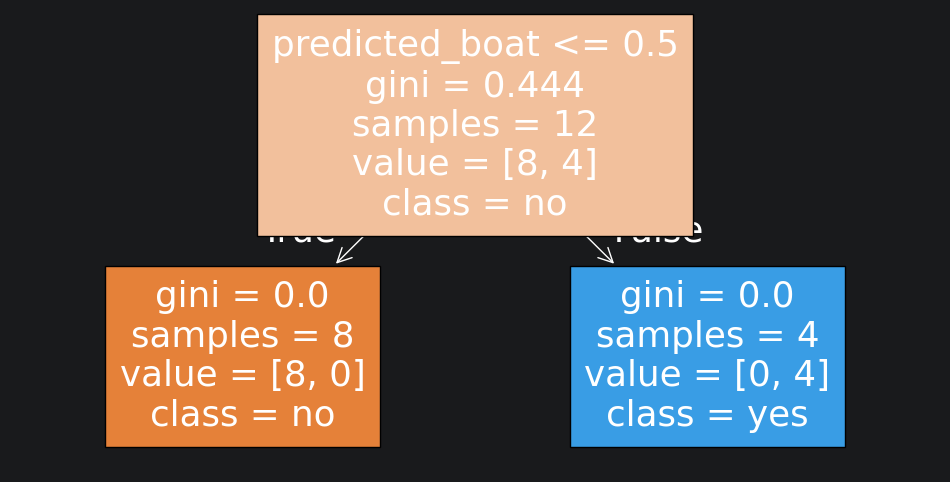

In [7]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plot_tree(model, feature_names=X.columns, class_names=["no","yes"], filled=True)
plt.show()

Compare with your rule

Your rule:

In [9]:
def rule(row):
    return (
        row["age"] > 45 and
        (row["children"] < 3 or row["marital"] != "divorced")
    )

Evaluate both:

In [11]:
data["rule_pred"] = data.apply(rule, axis=1).map({True:"yes", False:"no"})
data["tree_pred"] = model.predict(X)
data

,age,cars,house,children,marital,dog,boat,predicted_boat,rule_pred,tree_pred
0,66,1,yes,2,widowed,no,yes,True,yes,yes
1,52,2,yes,3,married,no,yes,True,yes,yes
2,22,0,no,0,married,yes,no,False,no,no
3,25,1,no,1,single,no,no,False,no,no
4,44,0,no,2,divorced,yes,no,False,no,no
5,39,1,yes,2,married,yes,no,False,no,no
6,26,1,no,2,single,no,no,False,no,no
7,40,3,yes,1,married,yes,no,False,no,no
8,53,2,yes,2,divorced,no,yes,True,yes,yes
9,64,2,yes,3,divorced,no,no,False,no,no


Accuracy comparison

In [12]:
from sklearn.metrics import accuracy_score

print("Rule accuracy:", accuracy_score(y, data["rule_pred"]))
print("Tree accuracy:", accuracy_score(y, data["tree_pred"]))

Rule accuracy: 1.0
Tree accuracy: 1.0
